This notebook analyzes the Boulder dataset from NIST linked https://nextg.nist.gov/submissions/112. The first half of the notebook is from tutorial #5 to process the data. 

In [1]:
import glob
from scipy.io import loadmat

import os
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver

from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import math
import random

import sys

sys.path.append(os.path.abspath('./src'))
from scene_generation.core import Scene
from scene_generation.utils import rect_from_point_and_size, get_utm_epsg_code_from_gps, gps_to_utm_xy, get_center_subarray
from scene_generation.empirical_pathloss_model import pathloss_38901
from scene_generation.unet.unet_model_rt import UNet

# Mitsuba components for advanced scene operation
import mitsuba as mi
import drjit as dr

In [2]:
# LOS or NLOS for measurement type
MEASUREMENT_TYPE = "LOS"

In [3]:
# Initialize header data structure
header_dict = {"file_name":[], "mea_idx":[]}
header_folder_path = "./data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_{}/Header files/".format(MEASUREMENT_TYPE)  
header_mat_files = glob.glob(f"{header_folder_path}/*.mat")  
print(header_mat_files[:3]) 

['./data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_LOS/Header files/F0001599hdr.mat', './data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_LOS/Header files/F0001587hdr.mat', './data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_LOS/Header files/F0001595hdr.mat']


In [4]:
# MATLAB to Python data conversion
for mat_file_path in header_mat_files: 

    #Load the .mat file
    data = loadmat(mat_file_path)

    # Store basic file info
    header_dict["file_name"].append(os.path.basename(mat_file_path))
    header_dict["mea_idx"].append(os.path.basename(mat_file_path)[4:4+4])

    # Recursive struct parsing
    for key in data:
        if not key.startswith("__"):  # Ignore metadata keys
            value = data[key]
            if isinstance(value, np.ndarray) and value.dtype.names:
                    for name in value.dtype.names:
                        tmp_value =  data[key][0][name]
                        try:
                            tmp_value = tmp_value.item()
                            tmp_value = tmp_value.squeeze()
                            tmp_value = tmp_value.item()
                        except Exception as e:
                            pass
                        if ("{}_{}".format(key, name)) not in header_dict:
                            header_dict[("{}_{}".format(key, name))] = []
                        header_dict[("{}_{}".format(key, name))].append(tmp_value)
            else:
                tmp_value = data[key]
                try:
                    tmp_value = tmp_value.item()
                    tmp_value = tmp_value.squeeze()
                    tmp_value = tmp_value.item()
                except Exception as e:
                    pass
                if "{}".format(key) not in header_dict:
                    header_dict[("{}".format(key))] = []
                header_dict[("{}".format(key))].append(tmp_value)

In [5]:
header_df = pd.DataFrame(header_dict)
# print(header_df.iloc[0].to_string())

In [6]:
assert header_df['TxData_lat_Deg'].nunique() == 1,"Error: Mupltiple TX latitudes detected"
assert header_df['TxData_long_Deg'].nunique() == 1,"Error: Mupltiple TX longitudes detected" 
assert header_df['TxData_alt'].nunique() == 1,"Error: Mupltiple TX altitudes detected" 

In [7]:
# Initialize MPC data structure
MPC_dict = {"file_name":[],"mea_idx":[]}
MPC_folder_path = "./data/measurements/Boulder_Downtown/Measurements/BoulderDowntown_28GHz_{}/MPC files/".format(MEASUREMENT_TYPE)  
MPC_mat_files = glob.glob(f"{MPC_folder_path}/*.mat")  

#print(MPC_mat_files[:3]) 

In [8]:
for mat_file_path in MPC_mat_files:   
    data = loadmat(mat_file_path)
    MPC_dict["file_name"].append(os.path.basename(mat_file_path))
    MPC_dict["mea_idx"].append(os.path.basename(mat_file_path)[3:3+4])
    for key in data:
        if not key.startswith("__"):  # Ignore metadata keys
            value = data[key]
            if isinstance(value, np.ndarray) and value.dtype.names:
                    for name in value.dtype.names:
                        tmp_value =  data[key][0][name]
                        try:
                            tmp_value = tmp_value.item()
                            tmp_value = tmp_value.squeeze()
                            tmp_value = tmp_value.item()
                        except Exception as e:
                            pass
                        if ("{}_{}".format(key, name)) not in MPC_dict:
                            MPC_dict[("{}_{}".format(key, name))] = []
                        MPC_dict[("{}_{}".format(key, name))].append(tmp_value)
            else:
                tmp_value = data[key]
                try:
                    tmp_value = tmp_value.item()
                    tmp_value = tmp_value.squeeze()
                    tmp_value = tmp_value.item()
                except Exception as e:
                    pass
                if "{}".format(key) not in MPC_dict:
                    MPC_dict[("{}".format(key))] = []
                MPC_dict[("{}".format(key))].append(tmp_value)

In [9]:
MPC_df = pd.DataFrame(MPC_dict)
print(MPC_df.iloc[0].to_string())
print("\n")
# print(MPC_df.iloc[0]["MPC_params_sector01"])

file_name                                                            MPC1586.mat
mea_idx                                                                     1586
header_TxGainEffective_dBi                                                     2
header_TxHPBW_Effective_deg                                                 47.3
header_dist_m                                                           8.135848
header_NumSectors                                                              8
header_B2B_Attenuation_dB                                                    -15
MPC_params_sector01            [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector02            [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector03            [[27.175, 305.693498293, 2.0, 76.8856012035188...
MPC_params_sector04            [[27.175, 305.693498293, 2.0, 76.8748947325494...
MPC_params_sector05            [[27.175, 305.693498293, 2.0, 76.8502548139726...
MPC_params_sector06         

In [10]:
merged_df = pd.merge(MPC_df, header_df, on='mea_idx', how='inner')  
print(merged_df.iloc[0].to_string())

file_name_x                                                           MPC1586.mat
mea_idx                                                                      1586
header_TxGainEffective_dBi                                                      2
header_TxHPBW_Effective_deg                                                  47.3
header_dist_m                                                            8.135848
header_NumSectors                                                               8
header_B2B_Attenuation_dB                                                     -15
MPC_params_sector01             [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector02             [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector03             [[27.175, 305.693498293, 2.0, 76.8856012035188...
MPC_params_sector04             [[27.175, 305.693498293, 2.0, 76.8748947325494...
MPC_params_sector05             [[27.175, 305.693498293, 2.0, 76.8502548139726...
MPC_params_secto

In [11]:
for mat_file_path in MPC_mat_files:   
    data = loadmat(mat_file_path)
    MPC_dict["file_name"].append(os.path.basename(mat_file_path))
    MPC_dict["mea_idx"].append(os.path.basename(mat_file_path)[3:3+4])
    for key in data:
        if not key.startswith("__"):  # Ignore metadata keys
            value = data[key]
            if isinstance(value, np.ndarray) and value.dtype.names:
                    for name in value.dtype.names:
                        tmp_value =  data[key][0][name]
                        try:
                            tmp_value = tmp_value.item()
                            tmp_value = tmp_value.squeeze()
                            tmp_value = tmp_value.item()
                        except Exception as e:
                            pass
                        if ("{}_{}".format(key, name)) not in MPC_dict:
                            MPC_dict[("{}_{}".format(key, name))] = []
                        MPC_dict[("{}_{}".format(key, name))].append(tmp_value)
            else:
                tmp_value = data[key]
                try:
                    tmp_value = tmp_value.item()
                    tmp_value = tmp_value.squeeze()
                    tmp_value = tmp_value.item()
                except Exception as e:
                    pass
                if "{}".format(key) not in MPC_dict:
                    MPC_dict[("{}".format(key))] = []
                MPC_dict[("{}".format(key))].append(tmp_value)

In [12]:
MPC_df = pd.DataFrame(MPC_dict)
print(MPC_df.iloc[0].to_string())
print("\n")

file_name                                                            MPC1586.mat
mea_idx                                                                     1586
header_TxGainEffective_dBi                                                     2
header_TxHPBW_Effective_deg                                                 47.3
header_dist_m                                                           8.135848
header_NumSectors                                                              8
header_B2B_Attenuation_dB                                                    -15
MPC_params_sector01            [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector02            [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector03            [[27.175, 305.693498293, 2.0, 76.8856012035188...
MPC_params_sector04            [[27.175, 305.693498293, 2.0, 76.8748947325494...
MPC_params_sector05            [[27.175, 305.693498293, 2.0, 76.8502548139726...
MPC_params_sector06         

In [13]:
merged_df = pd.merge(MPC_df, header_df, on='mea_idx', how='inner')  
print(merged_df.iloc[0].to_string())

file_name_x                                                           MPC1586.mat
mea_idx                                                                      1586
header_TxGainEffective_dBi                                                      2
header_TxHPBW_Effective_deg                                                  47.3
header_dist_m                                                            8.135848
header_NumSectors                                                               8
header_B2B_Attenuation_dB                                                     -15
MPC_params_sector01             [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector02             [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector03             [[27.175, 305.693498293, 2.0, 76.8856012035188...
MPC_params_sector04             [[27.175, 305.693498293, 2.0, 76.8748947325494...
MPC_params_sector05             [[27.175, 305.693498293, 2.0, 76.8502548139726...
MPC_params_secto

In [14]:
scene_dir = "./scenes/Boulder_Downtown"

polygon_points_gps = rect_from_point_and_size(
    merged_df.iloc[0]["TxData_long_Deg"],
    merged_df.iloc[0]["TxData_lat_Deg"],
    "center", 
    512,
    512
)
min_lon, min_lat = polygon_points_gps[0]
max_lon, max_lat = polygon_points_gps[2]
print(
    f"Check the bbox at http://bboxfinder.com/#{min_lat:.{4}f},{min_lon:.{4}f},{max_lat:.{4}f},{max_lon:.{4}f}"
)
scene_instance = Scene()
scene_instance(
    polygon_points_gps,
    scene_dir,
    None,
    osm_server_addr="https://overpass-api.de/api/interpreter",
    lidar_calibration=False,
    generate_building_map=True,
    ground_material_type="mat-itu_concrete",
    rooftop_material_type = "mat-itu_metal",
    wall_material_type = "mat-itu_brick"
    
)

utm_epsg = get_utm_epsg_code_from_gps(
    merged_df.iloc[0]["TxData_long_Deg"],
    merged_df.iloc[0]["TxData_lat_Deg"],
)

top_left_coord_x_utm, top_left_coord_y_utm,_  =  gps_to_utm_xy(min_lon, max_lat, utm_epsg)
center_coord_x_utm, center_coord_y_utm, _ = gps_to_utm_xy(
    merged_df.iloc[0]["TxData_long_Deg"],
    merged_df.iloc[0]["TxData_lat_Deg"], 
    utm_epsg
)

Check the bbox at http://bboxfinder.com/#40.0148,-105.2823,40.0194,-105.2763


Parsing buildings: 100%|██████████| 152/152 [00:00<00:00, 821.94it/s]


In [15]:
scene = load_scene("{}/scene.xml".format(scene_dir))

2025-09-24 02:12:26 WARN wrk6 [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).

In [16]:
# Apply transformation and store in new columns
merged_df["GPSData_longitude_UTM"], merged_df["GPSData_latitude_UTM"], _ = zip(
    *merged_df.apply(lambda row: gps_to_utm_xy(row["GPSData_longitude_Deg"], row["GPSData_latitude_Deg"], utm_epsg), axis=1)
)

merged_df["Sionna_Rx_x"], merged_df["Sionna_Rx_y"] = zip(
    *merged_df.apply(lambda row: (row["GPSData_longitude_UTM"] - center_coord_x_utm, row["GPSData_latitude_UTM"] - center_coord_y_utm ), axis=1)
)

print(merged_df.iloc[0].to_string())

file_name_x                                                           MPC1586.mat
mea_idx                                                                      1586
header_TxGainEffective_dBi                                                      2
header_TxHPBW_Effective_deg                                                  47.3
header_dist_m                                                            8.135848
header_NumSectors                                                               8
header_B2B_Attenuation_dB                                                     -15
MPC_params_sector01             [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector02             [[27.150000000000002, 305.693498293, 2.0, 76.9...
MPC_params_sector03             [[27.175, 305.693498293, 2.0, 76.8856012035188...
MPC_params_sector04             [[27.175, 305.693498293, 2.0, 76.8748947325494...
MPC_params_sector05             [[27.175, 305.693498293, 2.0, 76.8502548139726...
MPC_params_secto

In [17]:
merged_df = merged_df.drop_duplicates(subset=['mea_idx'])

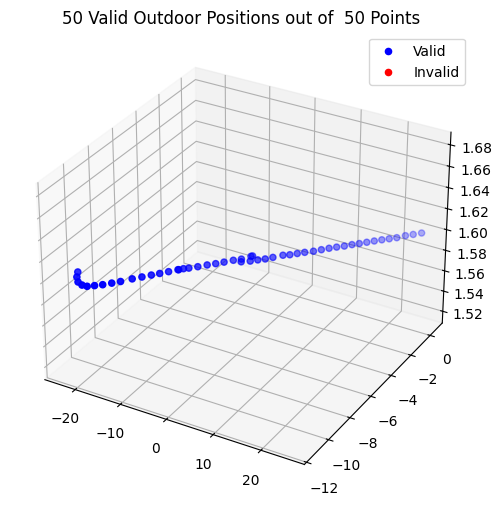

In [18]:
# Obtain the Mitsuba scene object from Sionna scene object 
mi_scene = scene.mi_scene

# Calculate scene bounding box excluding the ground plane
bbox = mi.ScalarBoundingBox3f()
for shape in mi_scene.shapes():
    if "ground" not in shape.id():
        bbox.expand(shape.bbox())

# Generate candidate positions (with a typical UE height of 1.5m)
# num_candidates = 1000
candidates = np.column_stack([
    merged_df["Sionna_Rx_x"].to_numpy(),
    merged_df["Sionna_Rx_y"].to_numpy(),
    merged_df["RxData_Rxh_m"].to_numpy()
])

# Create a direction vector pointing upwards (towards the sky) 
#  and tile it to match the number of positions
directions_np = np.tile(np.array([0, 0, 1]), (len(merged_df), 1))

# Ray tracing validation
rays = mi.Ray3f(
    # mi.Vector3f(candidates),
    mi.Vector3f(np.array(candidates, dtype=np.float32).T),
    mi.Vector3f(np.array(directions_np, dtype=np.float32).T)
)
si = mi_scene.ray_intersect(rays)
valid_mask = ~si.is_valid()

merged_df["is_outdoor"] = valid_mask

# Filter and visualize
valid_positions = candidates[valid_mask]
invalid_positions = candidates[~valid_mask]
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(valid_positions[:,0], valid_positions[:,1], valid_positions[:,2],c="blue",label="Valid")
ax.scatter(invalid_positions[:,0], invalid_positions[:,1], invalid_positions[:,2], c="red", label="Invalid" )
# Add legend
ax.legend()
ax.set_title(f"{len(valid_positions)} Valid Outdoor Positions out of  {len(merged_df)} Points")
plt.show()

In [19]:
# import drjit as dr
# import mitsuba as mi
# import numpy as np

# def v_custom_tx_pattern(theta: mi.Float, phi: mi.Float) -> mi.Complex2f:
#     """
#     Custom vertically polarized antenna pattern for TX:
#     - Omni-directional in azimuth (phi)
#     - 30° beamwidth in elevation (theta)
    
#     :param theta: Elevation angle [rad] (0 = zenith, π/2 = horizon, π = nadir)
#     :param phi: Azimuth angle [rad]
#     :return: Complex antenna pattern
#     """
    
#     # 30° beamwidth means -3dB points are at ±15° from boresight
#     # Assuming boresight is at θ = π/2 (horizon)
#     theta_3db = 15.0 * dr.pi / 180.0  # 15° in radians
#     boresight_theta = dr.pi / 2.0     # Horizon direction
    
#     # Gaussian-like pattern in elevation with 30° beamwidth
#     theta_offset = dr.abs(theta - boresight_theta)
    
#     # Calculate pattern using Gaussian approximation
#     # For 30° beamwidth (-3dB at ±15°), we need appropriate sigma
#     sigma = theta_3db / dr.sqrt(2.0 * dr.log(2.0))  # Convert FWHM to Gaussian sigma
#     elevation_pattern = dr.exp(-0.5 * (theta_offset / sigma)**2)
    
#     # Alternative: Use cosine-based pattern (more realistic for dipole-like)
#     # elevation_pattern = dr.maximum(dr.cos(theta_offset / theta_3db * dr.pi/4), 0.0)
    
#     # Omni-directional in azimuth (no phi dependence)
#     azimuth_pattern = 1.0
    
#     # Combine patterns
#     c_theta = elevation_pattern * azimuth_pattern
    
#     return mi.Complex2f(c_theta, 0)

# # Register the custom pattern
# from sionna.rt.antenna_pattern import register_antenna_pattern, PolarizedAntennaPattern

# def create_custom_tx_factory():
#     """Factory function for custom TX antenna pattern"""
#     def f(*, polarization, polarization_model="tr38901_2"):
#         return PolarizedAntennaPattern(
#             v_pattern=v_custom_tx_pattern,
#             polarization=polarization,
#             polarization_model=polarization_model
#         )
#     return f

# # Register the custom pattern
# register_antenna_pattern("custom_tx", create_custom_tx_factory())

# # Usage example:
# # For your TX configuration, you would use:
# tx_array = PlanarArray(
#     num_rows=1, 
#     num_cols=1, 
#     pattern="custom_tx", 
#     polarization="V"
# )

# # Transmitter configuration
# tx = Transmitter(
#     name="tx",
#     position=[0, 0, float(merged_df.iloc[0]["TxData_Txh_m"])],  # Elevated position
#     orientation=[0, 0, 0]  
# )
# scene.add(tx)

In [20]:
# Transmitter array (single isotropic element)
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",        # isotropic pattern
    polarization="V"      # vertical polarization
)

# Receive array (single dipole element)
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V"
)

# Transmitter configuration
tx = Transmitter(
    name="tx",
    position=[0, 0, float(merged_df.iloc[0]["TxData_Txh_m"])],  # Elevated position
    orientation=[0, 0, 0]  
)
scene.add(tx)

# Select 10 receivers form valid_positions (Outdoor positions)
# // for i, pos in enumerate(valid_positions[np.random.choice(valid_positions.shape[0], size=5, replace=False)]):
for index, row in merged_df.iterrows():
    if merged_df.iloc[index]['is_outdoor'] == True:
        rx = Receiver(
                name=f"rx_{row['mea_idx']}",
                position=(row["Sionna_Rx_x"], row["Sionna_Rx_y"] , row["RxData_Rxh_m"]),
                orientation=[0, 0, 0] 
            )
        scene.add(rx)
        

In [21]:
import sionna.rt
from sionna.rt import SceneObject, ITURadioMaterial

def add_random_cars_to_scene(scene, num_cars, area_radius, valid_positions):
        # Radio material constituing the cars
        # Use ITU metal, and use red color for visualization to
        car_material = ITURadioMaterial("car-material",
                                        "metal",
                                        thickness=0.01,
                                        color=(0.8, 0.1, 0.1))

        # Instantiate `num_cars` cars sharing the same mesh and material
        cars = [SceneObject(fname=sionna.rt.scene.low_poly_car, # Simple mesh of a car
                        name=f"car-{i}",
                        radio_material=car_material)
                for i in range(num_cars)]

        # Add the list of newly instantiated objects to the scene
        scene.edit(add=cars)
        car_positions = []
        min_dist_rx = 2.0  # Minimum distance from any RX
        while len(car_positions) < num_cars:
                # Randomly sample a position within the defined area
                x = np.random.uniform(-area_radius, area_radius)
                y = np.random.uniform(-area_radius, area_radius)
                position = (x, y, 0)

                # Ensure x, y is not too close to the TX
                if np.linalg.norm(np.array(position) - np.array([0, 0, 0])) < min_dist_rx:
                        continue
                # Ensure x, y is not too close to any RX
                diffs = np.linalg.norm(valid_positions[:, :2] - np.array(position[:2]), axis=1)
                if np.any(diffs < min_dist_rx):
                        continue

                # Ensure the new position is not too close to existing cars
                if all(np.linalg.norm(np.array(position) - np.array(existing_pos)) >= min_dist_rx for existing_pos in car_positions):
                        car_positions.append(position)

        c = mi.Point3f(0, 0, 0)

        # Sample random coords
        x = np.random.uniform(-area_radius, area_radius, num_cars)
        y = np.random.uniform(-area_radius, area_radius, num_cars)
        z = np.zeros(num_cars)

        cars_positions = mi.Point3f(x, y, z)

        # Set positions/orientations
        for i in range(num_cars):
                cars[i].position = mi.Point3f(float(x[i]), float(y[i]), 0.0)
                cars[i].scaling = 2.0
        return scene        


In [22]:
LOS_scene = add_random_cars_to_scene(scene=scene, num_cars=10, area_radius=50, valid_positions=valid_positions)

In [23]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.patches import Circle
# import matplotlib.patches as mpatches

# def custom_tx_pattern_numpy(theta, phi=0):
#     """
#     NumPy version of the custom TX pattern for plotting
    
#     :param theta: Elevation angle [rad] (0 = zenith, π/2 = horizon, π = nadir)
#     :param phi: Azimuth angle [rad] (not used, omni-directional)
#     :return: Pattern amplitude
#     """
#     # 30° beamwidth means -3dB points are at ±15° from boresight
#     theta_3db = 30.0 * np.pi / 180.0  # 15° in radians
#     boresight_theta = np.pi / 2.0     # Horizon direction
    
#     # Gaussian-like pattern in elevation
#     theta_offset = np.abs(theta - boresight_theta)
    
#     # Calculate pattern using Gaussian approximation
#     sigma = theta_3db / np.sqrt(2.0 * np.log(2.0))
#     elevation_pattern = np.exp(-0.5 * (theta_offset / sigma)**2)
    
#     return elevation_pattern

# def plot_elevation_pattern():
#     """Plot the radiation pattern in elevation domain"""
    
#     # Create theta range (elevation angles)
#     theta_deg = np.linspace(-90, 90, 361)  # -90° to +90° in degrees
#     theta_rad = np.deg2rad(theta_deg)
    
#     # Convert to standard spherical coordinates (0 = zenith)
#     theta_spherical = np.pi/2 - theta_rad  # Convert from elevation to spherical
    
#     # Calculate pattern
#     pattern_linear = custom_tx_pattern_numpy(theta_spherical)
#     pattern_db = 20 * np.log10(pattern_linear + 1e-10)  # Convert to dB
    
#     # Create figure with subplots
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
#     # Plot 1: Cartesian plot
#     ax1.plot(theta_deg, pattern_db, 'b-', linewidth=2, label='Elevation Pattern')
#     ax1.axhline(y=-3, color='r', linestyle='--', alpha=0.7, label='-3dB Line')
#     ax1.axvline(x=0, color='k', linestyle=':', alpha=0.5, label='Boresight (Horizon)')
    
#     # Mark -3dB points
#     ax1.axvline(x=15, color='r', linestyle='--', alpha=0.7)
#     ax1.axvline(x=-15, color='r', linestyle='--', alpha=0.7)
    
#     ax1.set_xlabel('Elevation Angle (degrees)')
#     ax1.set_ylabel('Pattern Gain (dB)')
#     ax1.set_title('Antenna Pattern - Elevation Domain (Cartesian)')
#     ax1.grid(True, alpha=0.3)
#     ax1.legend()
#     ax1.set_ylim(-20, 2)
#     ax1.set_xlim(-90, 90)
    
#     # Add annotations for beamwidth
#     ax1.annotate('30° Beamwidth\n(-3dB)', xy=(0, -3), xytext=(30, -10),
#                 arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
#                 fontsize=10, ha='center', color='red')
    
#     # Plot 2: Polar plot
#     theta_polar = np.deg2rad(theta_deg + 90)  # Adjust for polar plot (0° at top)
    
#     ax2 = plt.subplot(122, projection='polar')
#     ax2.plot(theta_polar, pattern_linear, 'b-', linewidth=2, label='Elevation Pattern')
    
#     # Add -3dB circle
#     theta_circle = np.linspace(0, 2*np.pi, 100)
#     r_3db = np.sqrt(0.5)  # -3dB corresponds to 0.707 in linear scale
#     ax2.plot(theta_circle, np.full_like(theta_circle, r_3db), 'r--', alpha=0.7, label='-3dB Circle')
    
#     ax2.set_theta_zero_location('N')  # 0° at top
#     ax2.set_theta_direction(1)  # Clockwise
#     ax2.set_title('Antenna Pattern - Elevation Domain (Polar)', pad=20)
#     ax2.set_ylim(0, 1.1)
#     ax2.set_thetagrids(np.arange(0, 360, 30))
#     ax2.grid(True, alpha=0.3)
    
#     # Add degree labels for elevation
#     elevation_labels = ['-90°', '-60°', '-30°', '0°', '30°', '60°', '90°', '120°', 
#                        '150°', '180°', '210°', '240°']
#     ax2.set_thetagrids(np.arange(0, 360, 30), elevation_labels)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Print pattern characteristics
#     print("\nAntenna Pattern Characteristics:")
#     print(f"Boresight direction: 0° elevation (horizon)")
#     print(f"Peak gain: {np.max(pattern_db):.2f} dB")
#     print(f"Beamwidth (-3dB): 30°")
#     print(f"-3dB points: ±15° from boresight")
    
#     # Find actual -3dB points
#     idx_3db = np.where(pattern_db >= -3.1)[0]  # Small tolerance
#     if len(idx_3db) > 0:
#         beamwidth_actual = theta_deg[idx_3db[-1]] - theta_deg[idx_3db[0]]
#         print(f"Actual -3dB beamwidth: {beamwidth_actual:.1f}°")
    
#     return theta_deg, pattern_db, pattern_linear

# def plot_3d_pattern():
#     """Plot 3D radiation pattern"""
    
#     # Create angular grids
#     theta = np.linspace(0, np.pi, 91)  # Elevation (0 to π)
#     phi = np.linspace(0, 2*np.pi, 181)  # Azimuth (0 to 2π)
#     THETA, PHI = np.meshgrid(theta, phi)
    
#     # Calculate pattern (omni in azimuth)
#     PATTERN = np.zeros_like(THETA)
#     for i in range(len(phi)):
#         PATTERN[i, :] = custom_tx_pattern_numpy(theta)
    
#     # Convert to Cartesian coordinates
#     X = PATTERN * np.sin(THETA) * np.cos(PHI)
#     Y = PATTERN * np.sin(THETA) * np.sin(PHI)
#     Z = PATTERN * np.cos(THETA)
    
#     # Create 3D plot
#     fig = plt.figure(figsize=(10, 8))
#     ax = fig.add_subplot(111, projection='3d')
    
#     # Plot surface
#     surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, 
#                           linewidth=0.1, edgecolor='none')
    
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_zlabel('Z')
#     ax.set_title('3D Antenna Radiation Pattern\n(Omni in Azimuth, 30° Beamwidth in Elevation)')
    
#     # Add colorbar
#     plt.colorbar(surf, shrink=0.6, aspect=20, label='Pattern Amplitude')
    
#     # Set equal aspect ratio
#     max_range = 1.0
#     ax.set_xlim([-max_range, max_range])
#     ax.set_ylim([-max_range, max_range])
#     ax.set_zlim([0, max_range])
    
#     plt.tight_layout()
#     plt.show()

# def compare_patterns():
#     """Compare Gaussian vs Cosine pattern shapes"""
    
#     theta_deg = np.linspace(-90, 90, 361)
#     theta_rad = np.deg2rad(theta_deg)
#     theta_spherical = np.pi/2 - theta_rad
    
#     # Gaussian pattern (current implementation)
#     theta_3db = 15.0 * np.pi / 180.0
#     boresight_theta = np.pi / 2.0
#     theta_offset = np.abs(theta_spherical - boresight_theta)
#     sigma = theta_3db / np.sqrt(2.0 * np.log(2.0))
#     gaussian_pattern = np.exp(-0.5 * (theta_offset / sigma)**2)
    
#     # Cosine pattern (alternative)
#     cosine_pattern = np.maximum(np.cos(theta_offset / theta_3db * np.pi/4), 0.0)
    
#     # Convert to dB
#     gaussian_db = 20 * np.log10(gaussian_pattern + 1e-10)
#     cosine_db = 20 * np.log10(cosine_pattern + 1e-10)
    
#     plt.figure(figsize=(12, 5))
    
#     # Cartesian comparison
#     plt.subplot(121)
#     plt.plot(theta_deg, gaussian_db, 'b-', linewidth=2, label='Gaussian Pattern')
#     plt.plot(theta_deg, cosine_db, 'r-', linewidth=2, label='Cosine Pattern')
#     plt.axhline(y=-3, color='k', linestyle='--', alpha=0.7, label='-3dB Line')
#     plt.axvline(x=0, color='k', linestyle=':', alpha=0.5)
#     plt.xlabel('Elevation Angle (degrees)')
#     plt.ylabel('Pattern Gain (dB)')
#     plt.title('Pattern Comparison - Cartesian')
#     plt.grid(True, alpha=0.3)
#     plt.legend()
#     plt.xlim(-60, 60)
#     plt.ylim(-20, 2)
    
#     # Polar comparison
#     theta_polar = np.deg2rad(theta_deg + 90)
#     plt.subplot(122, projection='polar')
#     plt.plot(theta_polar, gaussian_pattern, 'b-', linewidth=2, label='Gaussian')
#     plt.plot(theta_polar, cosine_pattern, 'r-', linewidth=2, label='Cosine')
#     plt.title('Pattern Comparison - Polar')
#     plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
    
#     plt.tight_layout()
#     plt.show()

# if __name__ == "__main__":
#     print("Plotting Custom TX Antenna Radiation Pattern")
#     print("=" * 50)
    
#     # Plot main elevation pattern
#     theta_deg, pattern_db, pattern_linear = plot_elevation_pattern()
    
#     print("\n" + "="*50)
#     print("3D Radiation Pattern")
#     plot_3d_pattern()
    
#     print("\n" + "="*50)
#     print("Pattern Shape Comparison")
#     compare_patterns()

In [25]:
# Configure simulation parameters
scene.frequency = 28.5e9  
scene.synthetic_array = True  # Optimize for array calculations

# Set the transmitter array with custom pattern
# scene.tx_array = tx_array

for radio_material in scene.radio_materials.values():
    radio_material.scattering_coefficient  = 0.4

# Perform ray tracing using PathSolver()
solver = PathSolver()
paths = solver(scene, 
               max_depth=2,
               los=True,
               specular_reflection=True,
               diffuse_reflection=True, 
               refraction=False,
               samples_per_src=int(1e3)
)

In [40]:
# Preview the scene with paths
#scene.preview(paths=paths)
scene.preview()

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, matrixWorldNeedsUpda…

In [27]:
# Parse paths into a structured dataset containing detailed rays information
def create_ray_dataset(paths, frequency):
    """Process raw ray data into pandas DataFrame"""
    dataset = {
        'freq': [],
        'rx_id': [],
        'type': [],
        'phi_r': [],
        'phi_t': [],
        'theta_r': [],
        'theta_t': [],
        'a':[],
        'tau':[],
        'rx_coord':[]
    }

    # See sionna.rt.constants.InteractionType
    ray_type_map = {0: "LOS", 1: "SPECULAR", 2: "DIFFUSE", 4: "REFRACTION"}
    
    a = np.asarray(paths.a).squeeze()
    tau = np.asarray(paths.tau).squeeze()
    types = np.asarray(paths.interactions).squeeze()
    mask = np.asarray(paths.valid).squeeze()
    phi_r = np.asarray(paths.phi_r).squeeze()
    phi_t = np.asarray(paths.phi_t).squeeze()
    theta_r = np.asarray(paths.theta_r).squeeze()
    theta_t = np.asarray(paths.theta_t).squeeze()
    targets = np.asarray(paths.targets).squeeze().T
    
    # Extract relevant parameters
    for idx, item in enumerate(mask):
        # Filter out the RX if it has no valid paths
        if np.sum(item==True):
            for sub_idx, sub_item in enumerate(item):
                if sub_item:
                    cur_ray_type = 0
                    num_depths = types.shape[0]
                    for depth_idx in range(num_depths-1, -1, -1):
                        cur_ray_type = types[depth_idx,idx,sub_idx]
                        # print(f"types[{depth_idx},{idx},{sub_idx}]",cur_ray_type)
                        if cur_ray_type != 0:
                            break

                    # Store the list instead of np.array to avoid the space seperator in .csv
                    dataset["freq"].append(frequency)
                    dataset["type"].append(ray_type_map[cur_ray_type])
                    z = np.complex64(a[0,idx,sub_idx] + 1j*a[1, idx,sub_idx]) 
                    dataset["a"].append(z)
                    dataset["tau"].append(tau[idx,sub_idx])

                    # Paths object only store the RX position instead of the name/idx of the RX in the Scenes Object
                    # We need to obtain the RX name by calculating the nearest RX pos due to the precision issue
                    nearest_row = merged_df.loc[
                        merged_df.apply(lambda row: (row['Sionna_Rx_x'] - targets[idx, 0])**2 + (row['Sionna_Rx_y'] - targets[idx, 1])**2, axis=1).idxmin()
                    ]
                    dataset["rx_id"].append(nearest_row["mea_idx"])
                
                    
                    dataset["rx_coord"].append(valid_positions[idx].tolist())
                    dataset["phi_r"].append(phi_r[idx,sub_idx ])                    
                    dataset["phi_t"].append(phi_t[idx,sub_idx])
                    dataset["theta_r"].append(theta_r[idx,sub_idx])
                    dataset["theta_t"].append(theta_t[idx,sub_idx])
    
    return pd.DataFrame(dataset)

# Generate analysis dataframe
df = create_ray_dataset(paths, frequency=28.5e9)
df.head(10)

,freq,rx_id,type,phi_r,phi_t,theta_r,theta_t,a,tau,rx_coord
0,2.850000e+10,1586,DIFFUSE,2.662266,-2.918278,1.743899,2.601883,5.028741e-07+0.000000e+ 00j,4.070268e-08,"[6.657859602186363, -4.551181522198021, 1.6]"
1,2.850000e+10,1586,DIFFUSE,3.108017,-1.510225,1.648600,1.609845,-2.816624e-07-5.295589e- 08j,2.602726e-07,"[6.657859602186363, -4.551181522198021, 1.6]"
2,2.850000e+10,1586,DIFFUSE,2.043625,1.959701,1.288838,1.266838,2.086117e-07+0.000000e+ 00j,3.445712e-07,"[6.657859602186363, -4.551181522198021, 1.6]"
3,2.850000e+10,1586,LOS,2.541972,-0.599621,1.459660,1.681933,1.255582e-04+0.000000e+ 00j,2.706813e-08,"[6.657859602186363, -4.551181522198021, 1.6]"
4,2.850000e+10,1586,DIFFUSE,2.597494,-0.868465,1.804471,2.629808,7.604868e-07+0.000000e+ 00j,3.261084e-08,"[6.657859602186363, -4.551181522198021, 1.6]"
5,2.850000e+10,1586,DIFFUSE,-2.520385,-1.395993,1.815977,1.860100,7.609453e-07+0.000000e+ 00j,5.120729e-08,"[6.657859602186363, -4.551181522198021, 1.6]"
6,2.850000e+10,1586,SPECULAR,2.541972,-0.599624,2.041127,2.041123,5.541186e-06-1.445900e- 06j,3.017794e-08,"[6.657859602186363, -4.551181522198021, 1.6]"
7,2.850000e+10,1586,DIFFUSE,2.271033,1.684757,1.714937,2.140687,2.645201e-07+0.000000e+ 00j,5.260095e-08,"[6.657859602186363, -4.551181522198021, 1.6]"
8,2.850000e+10,1586,DIFFUSE,3.068919,-2.662848,1.688155,1.883159,1.982798e-07+0.000000e+ 00j,7.269707e-08,"[6.657859602186363, -4.551181522198021, 1.6]"
9,2.850000e+10,1586,DIFFUSE,2.389600,1.181348,1.758221,2.659196,5.289751e-07+0.000000e+ 00j,3.805296e-08,"[6.657859602186363, -4.551181522198021, 1.6]"


In [28]:
def linear(pg_arr):
    pg_arr_copy = pg_arr.copy()
    return 10 ** (pg_arr_copy / 10)

def convert_to_db(pg_arr):
    pg_arr_copy = pg_arr.copy()
    return 10 * np.log10(pg_arr_copy)

def normalize(path_gain_arr):
    linear_pg = linear(path_gain_arr)
    max_val = np.max(linear_pg)
    linear_pg_norm = linear_pg / max_val
    return convert_to_db(linear_pg_norm)

In [29]:
def compare_real_vs_sionna(
    aoa_az_real,
    aoa_az_sionna,
    aoa_el_real,
    aoa_el_sionna,
    delay_real,
    delay_sionna,
    pg_real,
    pg_sionna,
    rx_id,
    norm_threshold
):
    fig = plt.figure(figsize=(14, 12))  # Adjust size as needed
    fig.suptitle(f'RX-{rx_id}', fontsize=16, fontweight='bold')

    # Plot 1: AoA Azimuth - Real
    ax1 = fig.add_subplot(3, 2, 1, polar=True)
    sc1 = ax1.scatter(np.deg2rad(aoa_az_real), pg_real, c=pg_real, cmap='viridis', s=50)
    ax1.set_ylim(max(pg_real), min(pg_real))
    ax1.set_title("AoA Azimuth - Real")
    plt.colorbar(sc1, ax=ax1, orientation='vertical')

    # Plot 2: AoA Azimuth - Simulated
    ax2 = fig.add_subplot(3, 2, 2, polar=True)
    sc2 = ax2.scatter(np.deg2rad(aoa_az_sionna), pg_sionna, c=pg_sionna, cmap='viridis', s=50)
    ax2.set_ylim(max(pg_sionna), min(pg_sionna))
    ax2.set_title("AoA Azimuth - Simulated")
    plt.colorbar(sc2, ax=ax2, orientation='vertical')

    # Plot 3: AoA Elevation - Real
    ax3 = fig.add_subplot(3, 2, 3, polar=True)
    sc3 = ax3.scatter(np.deg2rad(aoa_el_real), pg_real, c=pg_real, cmap='viridis', s=50)
    ax3.set_ylim(max(pg_real), min(pg_real))
    ax3.set_title("AoA Elevation - Real")
    plt.colorbar(sc3, ax=ax3, orientation='vertical')

    # Plot 4: AoA Elevation - Simulated
    ax4 = fig.add_subplot(3, 2, 4, polar=True)
    sc4 = ax4.scatter(np.deg2rad(aoa_el_sionna), pg_sionna, c=pg_sionna, cmap='viridis', s=50)
    ax4.set_ylim(max(pg_sionna), min(pg_sionna))
    ax4.set_title("AoA Elevation - Simulated")
    plt.colorbar(sc4, ax=ax4, orientation='vertical')

    # Plot 5: Delay Profile - Real
    # Apply threshold
    mask = pg_real >= norm_threshold
    delay_filtered = delay_real[mask]
    pg_filtered = pg_real[mask]

    # Find delay at max path gain (from filtered data)
    max_pg_idx = np.argmax(pg_filtered)
    delay_at_max_pg = delay_filtered[max_pg_idx]

    # Shift so delay_at_max_pg becomes 0
    delay_shifted = delay_filtered - delay_at_max_pg

    # Plot
    ax5 = fig.add_subplot(3, 2, 5)
    ax5.vlines(delay_shifted, ymin=0, ymax=pg_filtered, color='blue', linewidth=2)
    ax5.scatter(delay_shifted, pg_filtered, color='red')
    ax5.set_xlabel("Delay (ns)")
    ax5.set_ylabel("Norm Path Gain (dB)")
    ax5.set_title("Delay Profile - Real")
    ax5.grid(True)


    # Apply threshold
    mask_sionna = pg_sionna >= norm_threshold
    delay_sionna_filtered = delay_sionna[mask_sionna]
    pg_sionna_filtered = pg_sionna[mask_sionna]

    # Find delay at max path gain (from filtered data)
    sionna_max_pg_idx = np.argmax(pg_sionna_filtered)
    sionna_delay_at_max_pg = delay_sionna_filtered[sionna_max_pg_idx]

    # Shift so delay_at_max_pg becomes 0
    sionna_delay_shifted = delay_sionna_filtered - sionna_delay_at_max_pg

    # Plot
    ax6 = fig.add_subplot(3, 2, 6)
    ax6.vlines(sionna_delay_shifted, ymin=0, ymax=pg_sionna_filtered, color='blue', linewidth=2)
    ax6.scatter(sionna_delay_shifted, pg_sionna_filtered, color='red')
    ax6.set_xlabel("Delay (ns)")
    ax6.set_ylabel("Norm Path Gain (dB)")
    ax6.set_title("Delay Profile - Simulated")
    ax6.grid(True)


    plt.tight_layout()
    plt.show()


In [30]:
# comparison_df collects data from the strongest path ray from Sionna to compare with the strongest path ray from the Boulder data

comparison_df = pd.DataFrame()

for idx, rx_id in enumerate(merged_df['mea_idx']):
    # Get real results
    merged_df_row = merged_df[merged_df['mea_idx'] == rx_id]
    if merged_df_row['is_outdoor'].iloc[0] == True:
        tmp_tau = merged_df_row["MPC_params_sector01"].values[0][:, 0]
        tmp_aoa_az = merged_df_row["MPC_params_sector01"].values[0][:, 1]
        tmp_aoa_el = merged_df_row["MPC_params_sector01"].values[0][:, 2]
        tmp_path_gain = -1.0*merged_df_row["MPC_params_sector01"].values[0][:, 3]

        strongest_pg_idx = np.argmax(tmp_path_gain)

        # Get Sionna results
        tmp_df = df[df["rx_id"] == rx_id]
        tmp_tau_sionna = (tmp_df["tau"].values * 1e9)  # Convert to nsec
        tmp_aoa_az_sionna = (90 - (tmp_df["phi_r"].values * 180 / np.pi)) % 360
        tmp_aoa_el_sionna = (90 - (tmp_df["theta_r"].values * 180 / np.pi)) % 360

        tmp_aod_az_sionna = (90 - (tmp_df["phi_t"].values * 180 / np.pi)) % 360
        tmp_aod_el_sionna = (90 - (tmp_df["theta_t"].values * 180 / np.pi)) % 360
        tmp_path_gain_sionna = 10 * np.log10(np.abs(tmp_df["a"].values)**2)
        tmp_ray_type_sionna = tmp_df["type"]
        
        # Apply threshold
        threshold_value = -140
        mask = tmp_path_gain_sionna >= threshold_value

        # Apply mask to all arrays
        tmp_tau_sionna = tmp_tau_sionna[mask]
        tmp_aoa_az_sionna = tmp_aoa_az_sionna[mask]
        tmp_aoa_el_sionna = tmp_aoa_el_sionna[mask]
        tmp_path_gain_sionna = tmp_path_gain_sionna[mask]

        tmp_pg_norm = normalize(tmp_path_gain)

        if len(tmp_path_gain_sionna) > 0:
            threshold_pg_sionna_norm = normalize(np.array(list(tmp_path_gain_sionna)))
            
            ## Plot Comparisons
            ## Prints profiles of the first 5 receiver in list
            # if idx < 5:
            #     compare_real_vs_sionna(
            #         tmp_aoa_az, tmp_aoa_az_sionna,
            #         tmp_aoa_el, tmp_aoa_el_sionna,
            #         tmp_tau, tmp_tau_sionna,
            #         tmp_pg_norm, threshold_pg_sionna_norm,
            #         rx_id
            #     )

            # Add Strongest Rays
            strongest_sionna_pg_idx = np.argmax(tmp_path_gain_sionna)
            new_row_df = pd.DataFrame([{'rx_id':rx_id, 
                                    'Strongest PG (dB)': tmp_path_gain[strongest_pg_idx], 
                                    'AoA El': tmp_aoa_el[strongest_pg_idx] % 360,
                                    'AoA Az': tmp_aoa_az[strongest_pg_idx] % 360,
                                    'Delay (ns)': tmp_tau[strongest_pg_idx],
                                    'Strongest Sionna PG (dB)': tmp_path_gain_sionna[strongest_sionna_pg_idx],
                                    'Sionna AoA El': tmp_aoa_el_sionna[strongest_sionna_pg_idx] % 360,
                                    'Sionna AoA Az': tmp_aoa_az_sionna[strongest_sionna_pg_idx] % 360,
                                    'Sionna Delay (ns)': tmp_tau_sionna[strongest_sionna_pg_idx],
                                    'Sionna Ray Type': tmp_ray_type_sionna.iloc[strongest_sionna_pg_idx],
                                    'Sionna AoD El': tmp_aod_el_sionna[strongest_sionna_pg_idx] % 360,
                                    'Sionna AoD Az': tmp_aod_az_sionna[strongest_sionna_pg_idx] % 360}])

            comparison_df = pd.concat([comparison_df, new_row_df], ignore_index=True)
        else:
            print(f"No Sionna data available for rx_id {rx_id}, only printing real results.")

In [31]:
# Normalize path gain values
comparison_df['PG Norm (dB)'] = normalize(comparison_df['Strongest PG (dB)'])
comparison_df['Sionna PG Norm (dB)'] = normalize(comparison_df['Strongest Sionna PG (dB)'])

In [32]:
# 180 degree wrap around
def wrap_to_180(angle_series):
    return angle_series.where(angle_series >= 180, angle_series - 180)

# Apply to all relevant columns
cols = ['AoA Az', 'Sionna AoA Az', 'AoA El', 'Sionna AoA El']
comparison_df[cols] = comparison_df[cols].apply(wrap_to_180)


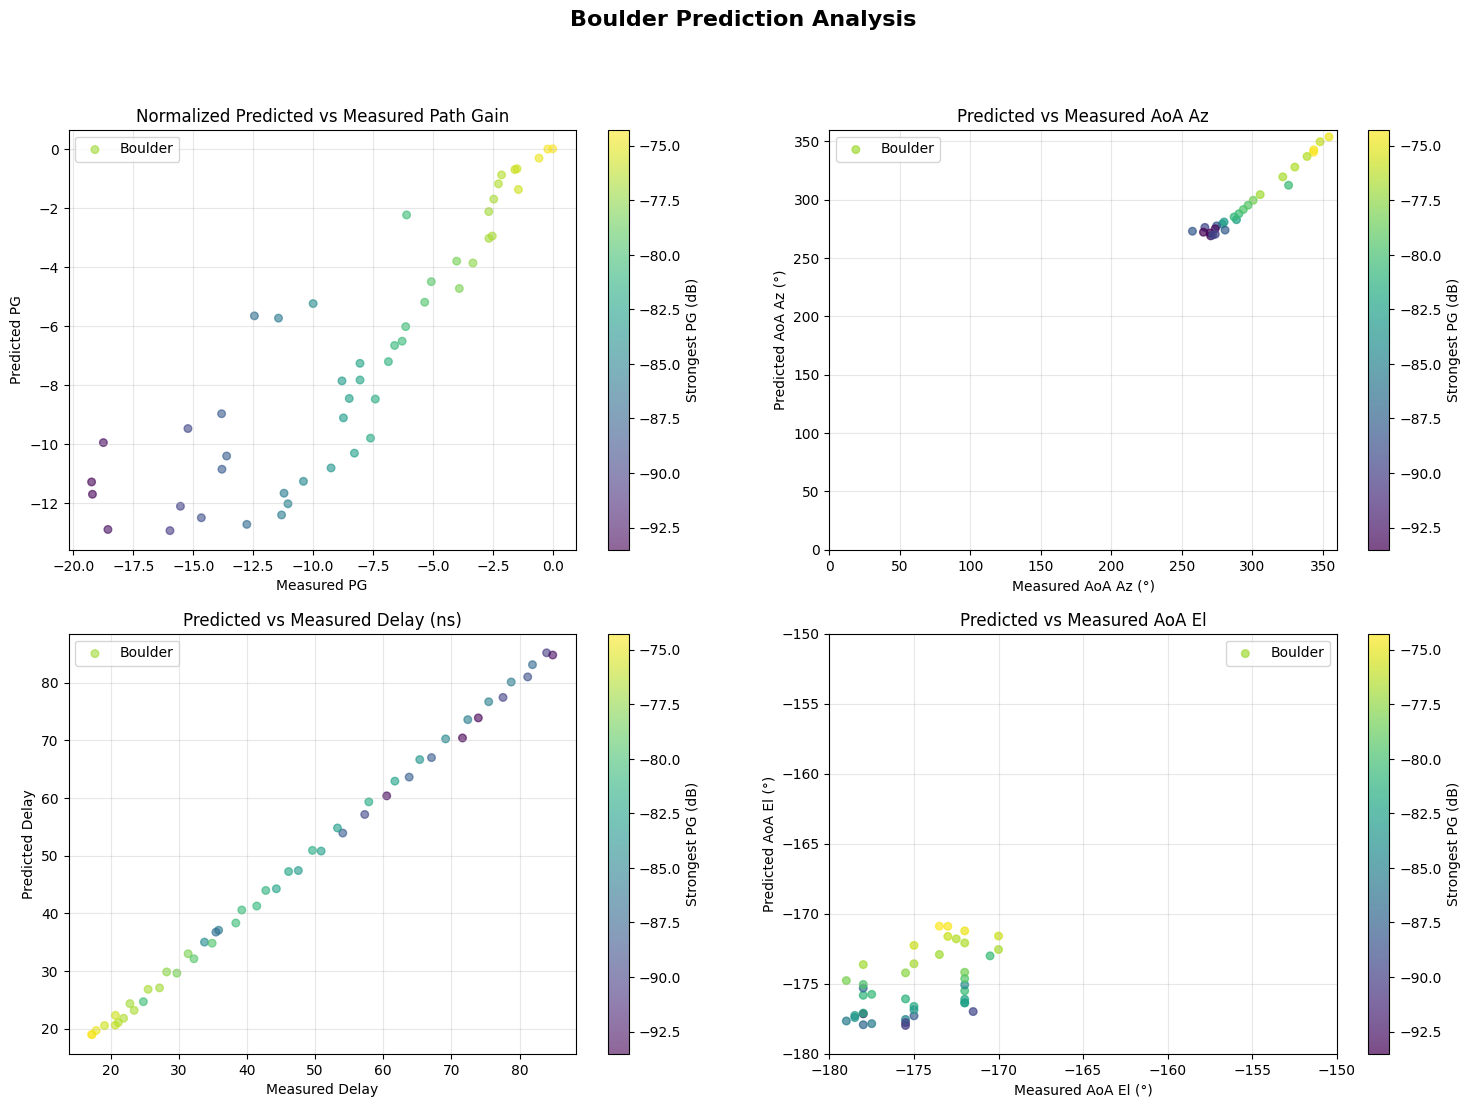

In [33]:
# Generating comparison plots with the color map being actual path gain results
# Perfect prediction lines can be adjusted based on whether measurement is NLOS or LOS

pg_colors = comparison_df['Strongest PG (dB)'] 

# Create Plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Boulder Prediction Analysis', fontsize=16, fontweight='bold')

# 1. Scatter plot: Path Gain
sc1 = axes[0, 0].scatter(comparison_df['PG Norm (dB)'], 
                         comparison_df['Sionna PG Norm (dB)'],
                         c=pg_colors,
                         cmap='viridis',  
                         alpha=0.6, 
                         s=30, 
                         label='Boulder')
# axes[0, 0].plot([-30, 0], [-30, 0], 'r--', label='Perfect Prediction')
axes[0, 0].set_xlabel('Measured PG')
axes[0, 0].set_ylabel('Predicted PG')
axes[0, 0].set_title('Normalized Predicted vs Measured Path Gain')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(sc1, ax=axes[0, 0])
cbar1.set_label('Strongest PG (dB)')

# 2. Scatter plot: Delay
sc2 = axes[1, 0].scatter(comparison_df['Delay (ns)'], 
                         comparison_df['Sionna Delay (ns)'], 
                         c=pg_colors,
                         cmap='viridis', 
                         alpha=0.6, 
                         s=30, 
                         label='Boulder')
# axes[1, 0].plot([200, 600], [200, 600], 'r--', label='Perfect Prediction')
axes[1, 0].set_xlabel('Measured Delay')
axes[1, 0].set_ylabel('Predicted Delay')
axes[1, 0].set_title('Predicted vs Measured Delay (ns)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
cbar2 = plt.colorbar(sc2, ax=axes[1, 0])
cbar2.set_label('Strongest PG (dB)')

# 3. Scatter plot: AoA Az with colormap
sc3 = axes[0, 1].scatter(
    comparison_df['AoA Az'], 
    comparison_df['Sionna AoA Az'], 
    c=pg_colors,
    cmap='viridis',   # choose your colormap here
    alpha=0.7, 
    s=30,
    label='Boulder'
)
# axes[0, 1].plot([100, 180], [100, 180], 'r--', label='Perfect Prediction')
axes[0, 1].set_xlim(0, 360)
axes[0, 1].set_ylim(0, 360)
axes[0, 1].set_xlabel('Measured AoA Az (°)')
axes[0, 1].set_ylabel('Predicted AoA Az (°)')
axes[0, 1].set_title('Predicted vs Measured AoA Az')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
cbar3 = plt.colorbar(sc3, ax=axes[0, 1])
cbar3.set_label('Strongest PG (dB)')

# 4. Scatter plot: AoA El with colormap
sc4 = axes[1, 1].scatter(
    comparison_df['AoA El'], 
    comparison_df['Sionna AoA El'], 
    c=pg_colors,
    cmap='viridis', 
    alpha=0.7, 
    s=30,
    label='Boulder'
)
# axes[1, 1].plot([0, 45], [0, 45], 'r--', label='Perfect Prediction')
axes[1, 1].set_xlim(-180, -150)
axes[1, 1].set_ylim(-180, -150)
axes[1, 1].set_xlabel('Measured AoA El (°)')
axes[1, 1].set_ylabel('Predicted AoA El (°)')
axes[1, 1].set_title('Predicted vs Measured AoA El')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
cbar4 = plt.colorbar(sc4, ax=axes[1, 1])
cbar4.set_label('Strongest PG (dB)')



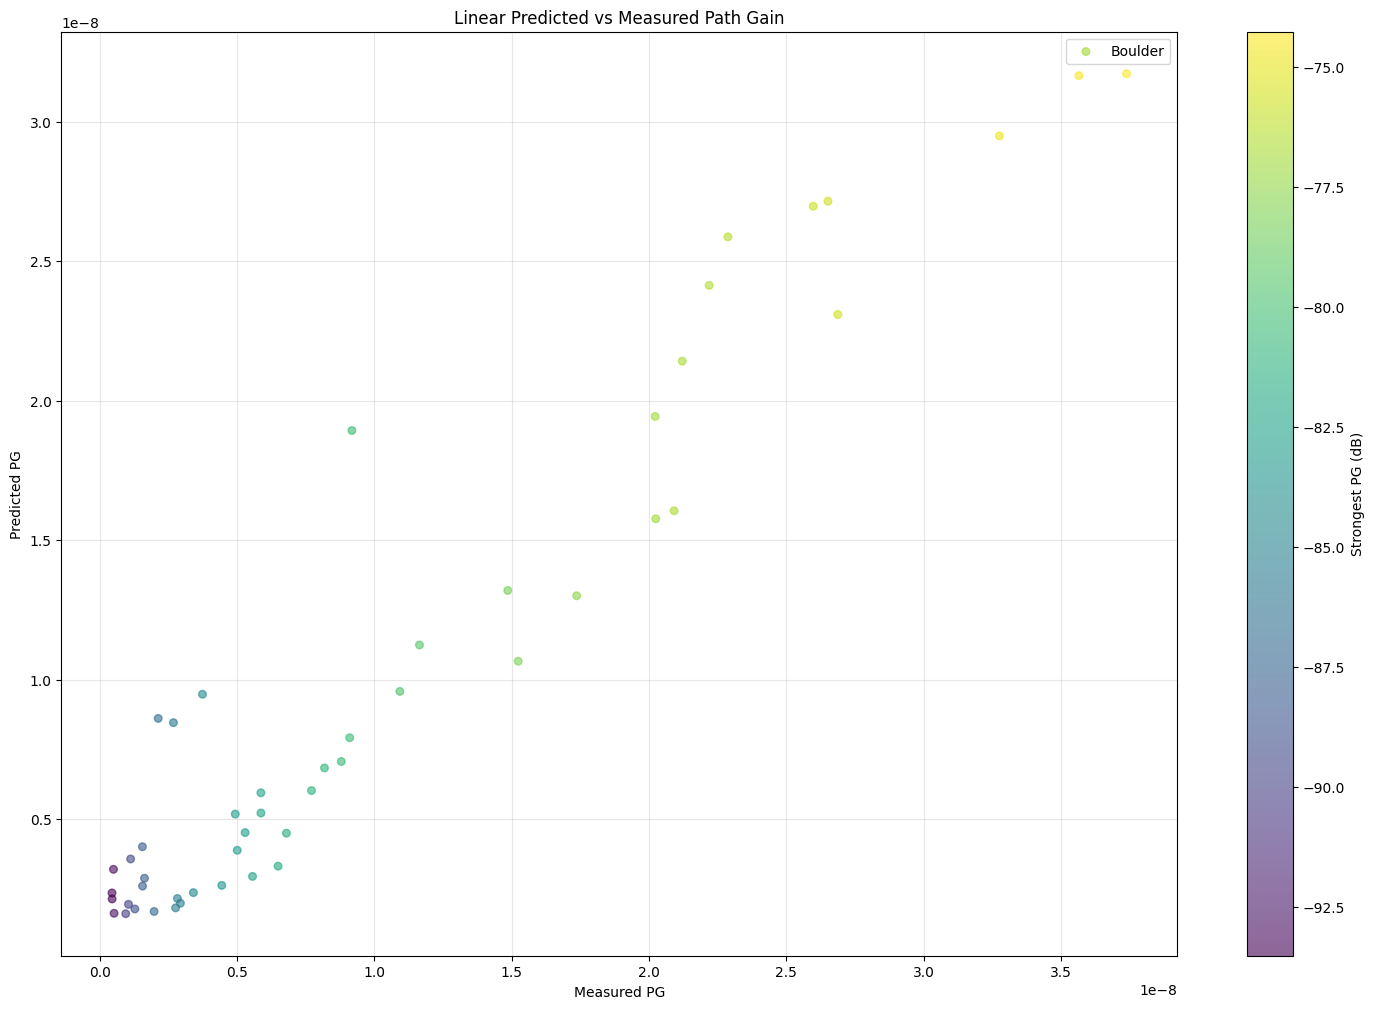

In [34]:
# Linear scatter plot
fig, axes = plt.subplots(1, 1, figsize=(18, 12))
sc = axes.scatter(linear(comparison_df['Strongest PG (dB)']), 
                         linear(comparison_df['Strongest Sionna PG (dB)']),
                         c=pg_colors,
                         cmap='viridis',  
                         alpha=0.6, 
                         s=30, 
                         label='Boulder')
#axes.plot([-30, 0], [-30, 0], 'r--', label='Perfect Prediction')
axes.set_xlabel('Measured PG')
axes.set_ylabel('Predicted PG')
axes.set_title('Linear Predicted vs Measured Path Gain')
axes.legend()
axes.grid(True, alpha=0.3)
cbar1 = plt.colorbar(sc, ax=axes)
cbar1.set_label('Strongest PG (dB)')


In [35]:
comparison_df['PG Absolute Error'] = np.abs(comparison_df['PG Norm (dB)'] - comparison_df['Sionna PG Norm (dB)'])
comparison_df.head(10)

,rx_id,Strongest PG (dB),AoA El,AoA Az,Delay (ns),Strongest Sionna PG (dB),Sionna AoA El,Sionna AoA Az,Sionna Delay (ns),Sionna Ray Type,Sionna AoD El,Sionna AoD Az,PG Norm (dB),Sionna PG Norm (dB),PG Absolute Error
0,1586,-76.936326,-178.0,305.693498,27.150,-78.023102,-173.632324,304.355743,27.068132,LOS,353.632324,124.355743,-2.664096,-3.036032,0.371936
1,1592,-82.315864,-172.0,288.878560,44.300,-82.259094,-176.110138,282.862671,44.253113,LOS,356.110138,102.862656,-8.043634,-7.272024,0.771610
2,1593,-83.067920,-172.0,280.079860,47.525,-82.854660,-176.369354,280.882385,47.407986,LOS,356.369354,100.882370,-8.795690,-7.867594,0.928096
3,1587,-78.280478,-172.0,300.781161,29.700,-78.795654,-174.182182,299.551300,29.616299,LOS,354.182190,119.551285,-4.008248,-3.808584,0.199664
4,2339,-74.272230,-173.5,343.501903,17.175,-74.987068,-170.889427,340.743530,18.959663,LOS,350.889435,160.743546,0.000000,0.000000,0.000000
5,1591,-80.871054,-178.0,287.177260,41.425,-81.652802,-175.826981,285.207489,41.255161,LOS,355.826965,105.207504,-6.598824,-6.665735,0.066911
6,1585,-80.370568,-170.5,325.852585,24.775,-77.228523,-173.010521,312.405090,24.670486,LOS,353.010529,132.405090,-6.098338,-2.241454,3.856884
7,1584,-76.734052,-170.0,321.738947,23.425,-76.692902,-172.555992,319.620941,23.171816,LOS,352.556000,139.620941,-2.461822,-1.705833,0.755989
8,1590,-80.409028,-172.0,290.615573,38.350,-81.014290,-175.506119,287.995544,38.314922,LOS,355.506104,107.995529,-6.136798,-6.027222,0.109576
9,2338,-74.478814,-173.0,343.774628,17.250,-74.996582,-170.899757,342.754242,18.980997,LOS,350.899750,162.754242,-0.206584,-0.009513,0.197071


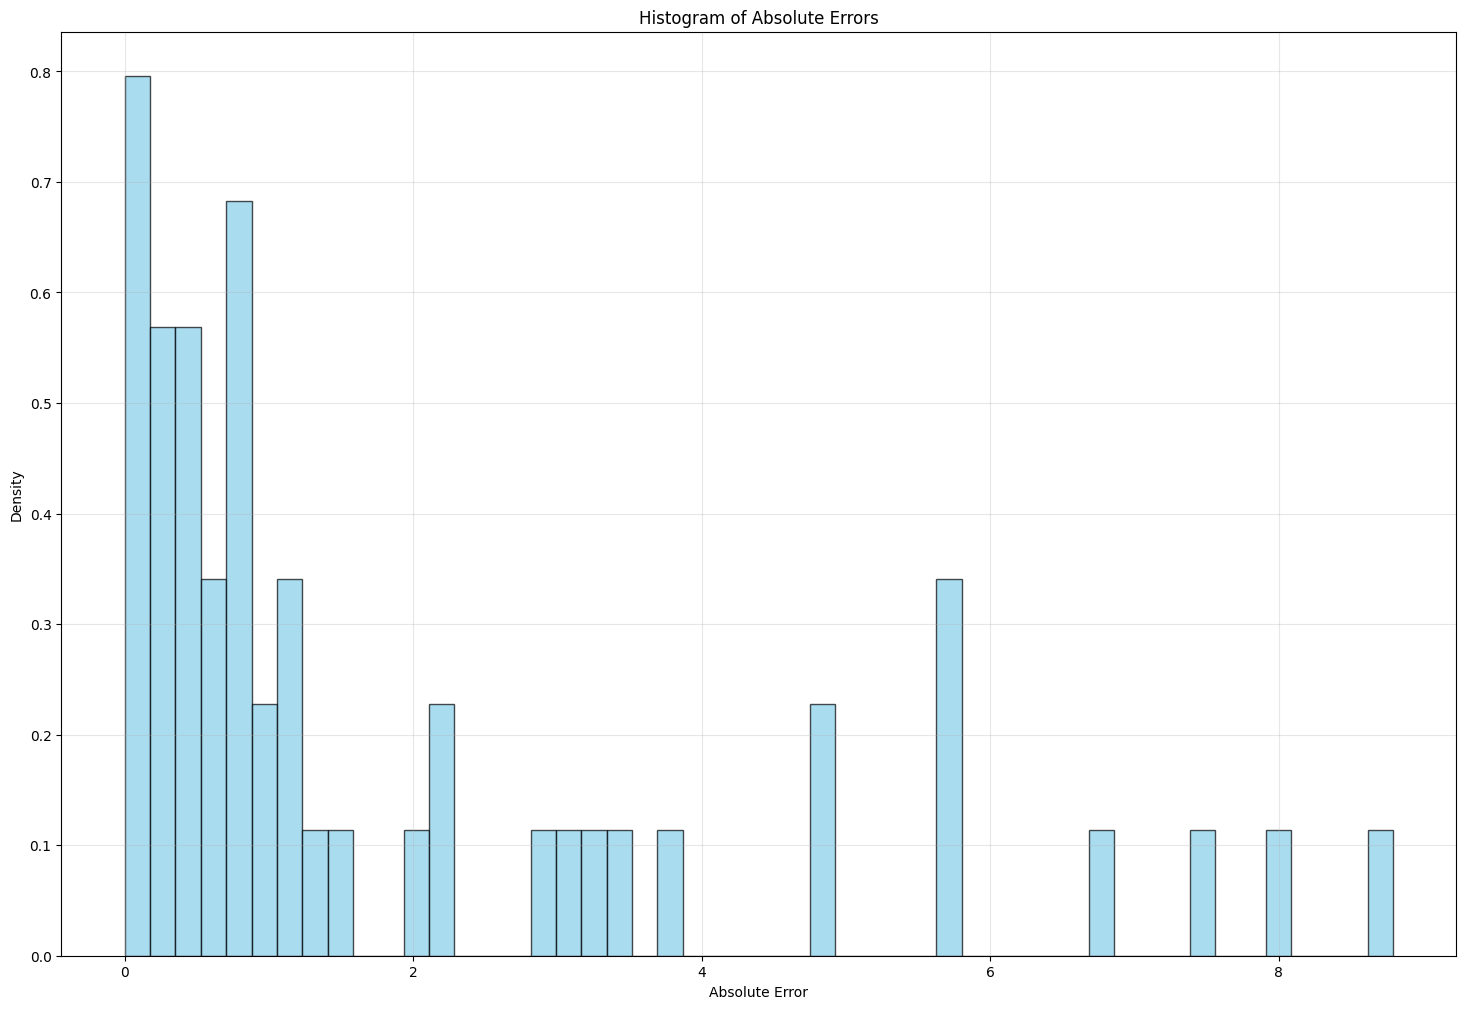

In [36]:
fig, axes = plt.subplots(1, 1, figsize=(18, 12))
axes.hist(comparison_df['PG Absolute Error'], bins=50, alpha=0.7, 
                color='skyblue', edgecolor='black', density=True)
axes.set_xlabel('Absolute Error')
axes.set_ylabel('Density')
axes.set_title('Histogram of Absolute Errors')
axes.grid(True, alpha=0.3)

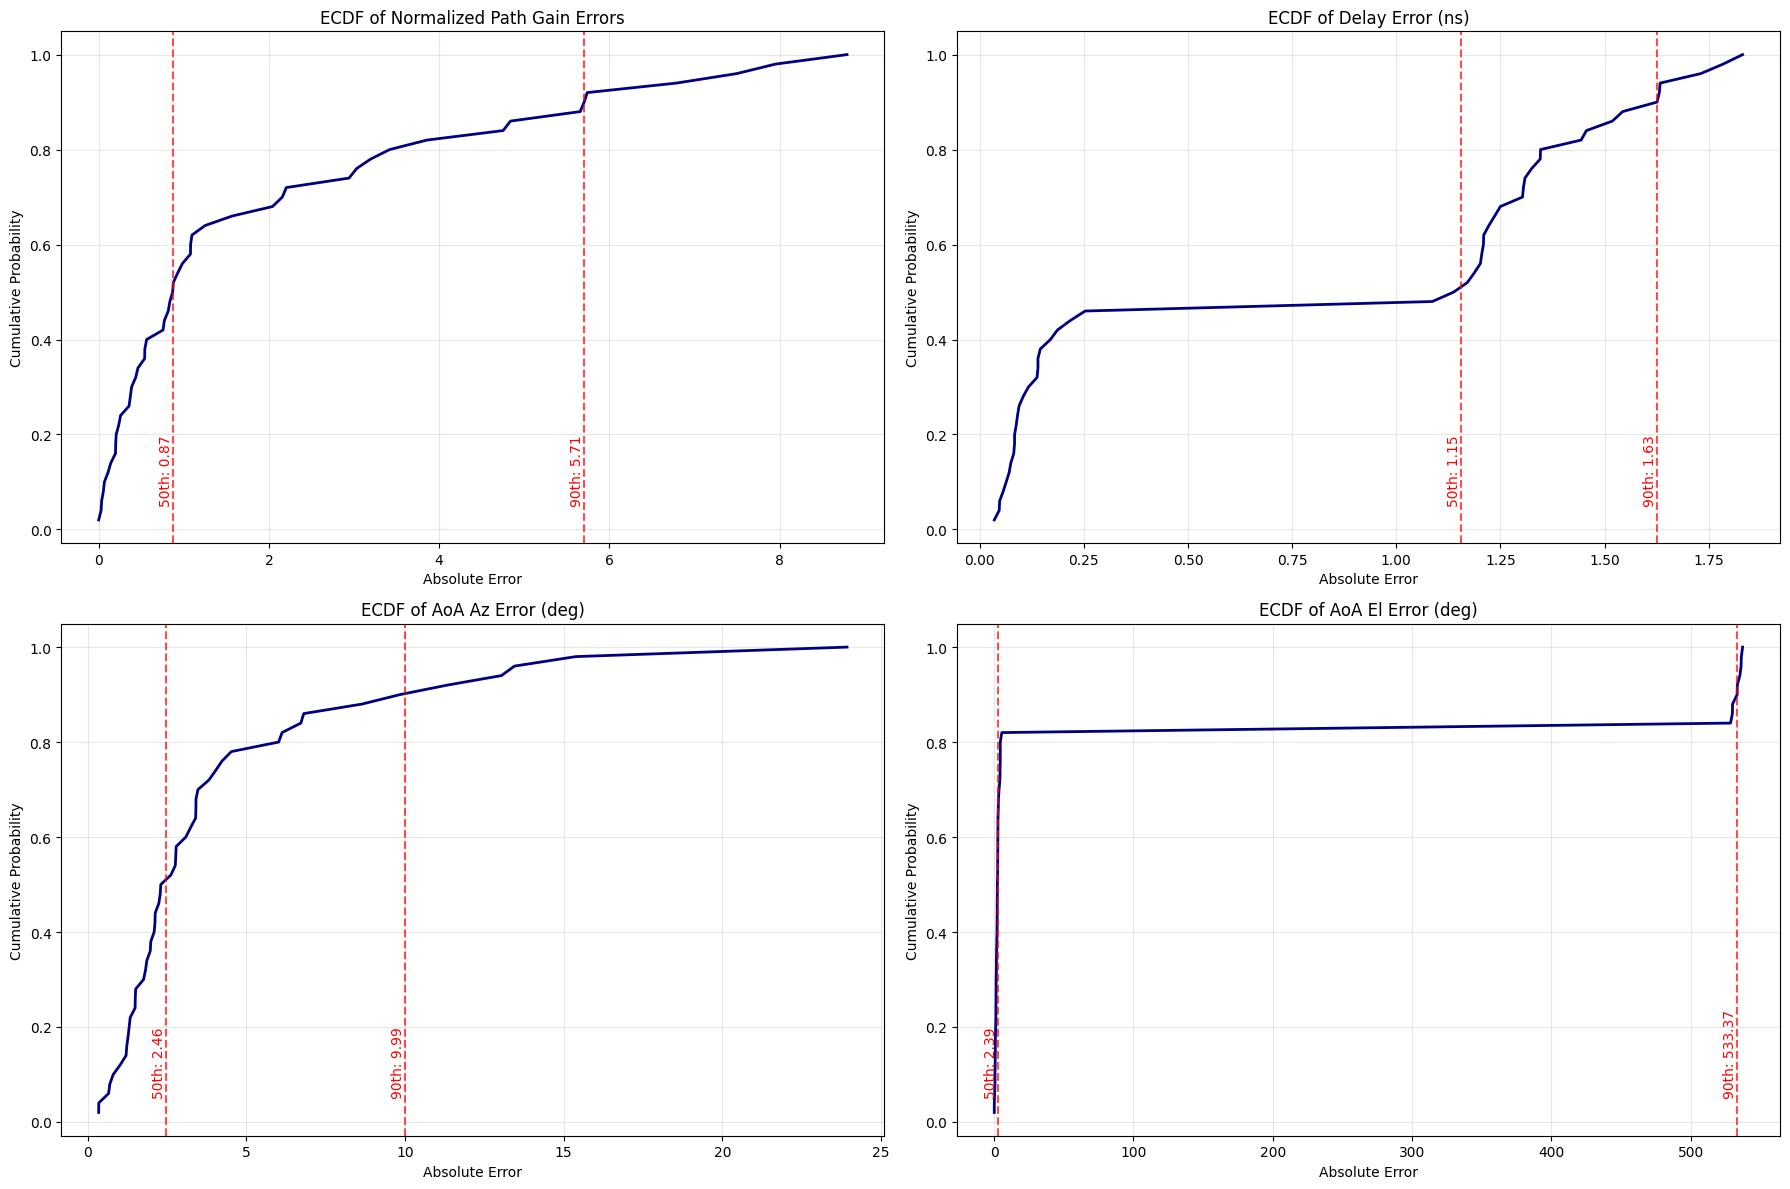

In [37]:
# Function to plot ecdf and percentiles
def plot_ecdf_with_percentiles(ax, errors, title, xlabel, percentiles=[50, 90]):
    sorted_errors = np.sort(errors)
    ecdf_y = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

    # Plot ECDF
    ax.plot(sorted_errors, ecdf_y, linewidth=2, color='navy')

    # Plot percentile lines
    for p in percentiles:
        val = np.percentile(sorted_errors, p)
        ax.axvline(val, linestyle='--', color='red', alpha=0.7)
        ax.text(val, 0.05, f'{p}th: {val:.2f}', rotation=90, va='bottom', ha='right', color='red')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Cumulative Probability')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Path Gain Error
plot_ecdf_with_percentiles(
    axes[0,0],
    comparison_df['PG Absolute Error'],
    'ECDF of Normalized Path Gain Errors',
    'Absolute Error'
)

# 2. Delay Error
plot_ecdf_with_percentiles(
    axes[0,1],
    np.abs(comparison_df['Sionna Delay (ns)'] - comparison_df['Delay (ns)']),
    'ECDF of Delay Error (ns)',
    'Absolute Error'
)

# 3. AoA Az Error
plot_ecdf_with_percentiles(
    axes[1,0],
    np.abs(comparison_df['Sionna AoA Az'] - comparison_df['AoA Az']),
    'ECDF of AoA Az Error (deg)',
    'Absolute Error'
)

# 4. AoA El Error
plot_ecdf_with_percentiles(
    axes[1,1],
    np.abs(comparison_df['Sionna AoA El'] - comparison_df['AoA El']),
    'ECDF of AoA El Error (deg)',
    'Absolute Error'
)

plt.tight_layout()
plt.show()


In [38]:
min_error_idx = comparison_df['PG Absolute Error'].idxmin()
min_error_row = comparison_df.loc[min_error_idx]
min_rx_id = min_error_row['rx_id']
min_val = min_error_row['PG Absolute Error']


max_error_idx = comparison_df['PG Absolute Error'].idxmax()
max_error_row = comparison_df.loc[max_error_idx]
max_rx_id = max_error_row['rx_id']
max_val = max_error_row['PG Absolute Error']

extremes_rx_id = [min_rx_id, max_rx_id]

print(f"Min Absolute Error (dB): {min_val}")
print(f"Max Absolute Error (dB): {max_val}")

Min Absolute Error (dB): 0.0
Max Absolute Error (dB): 8.79276023412313


Generating comparison profiles for the rx with the least and most amount of path gain error.

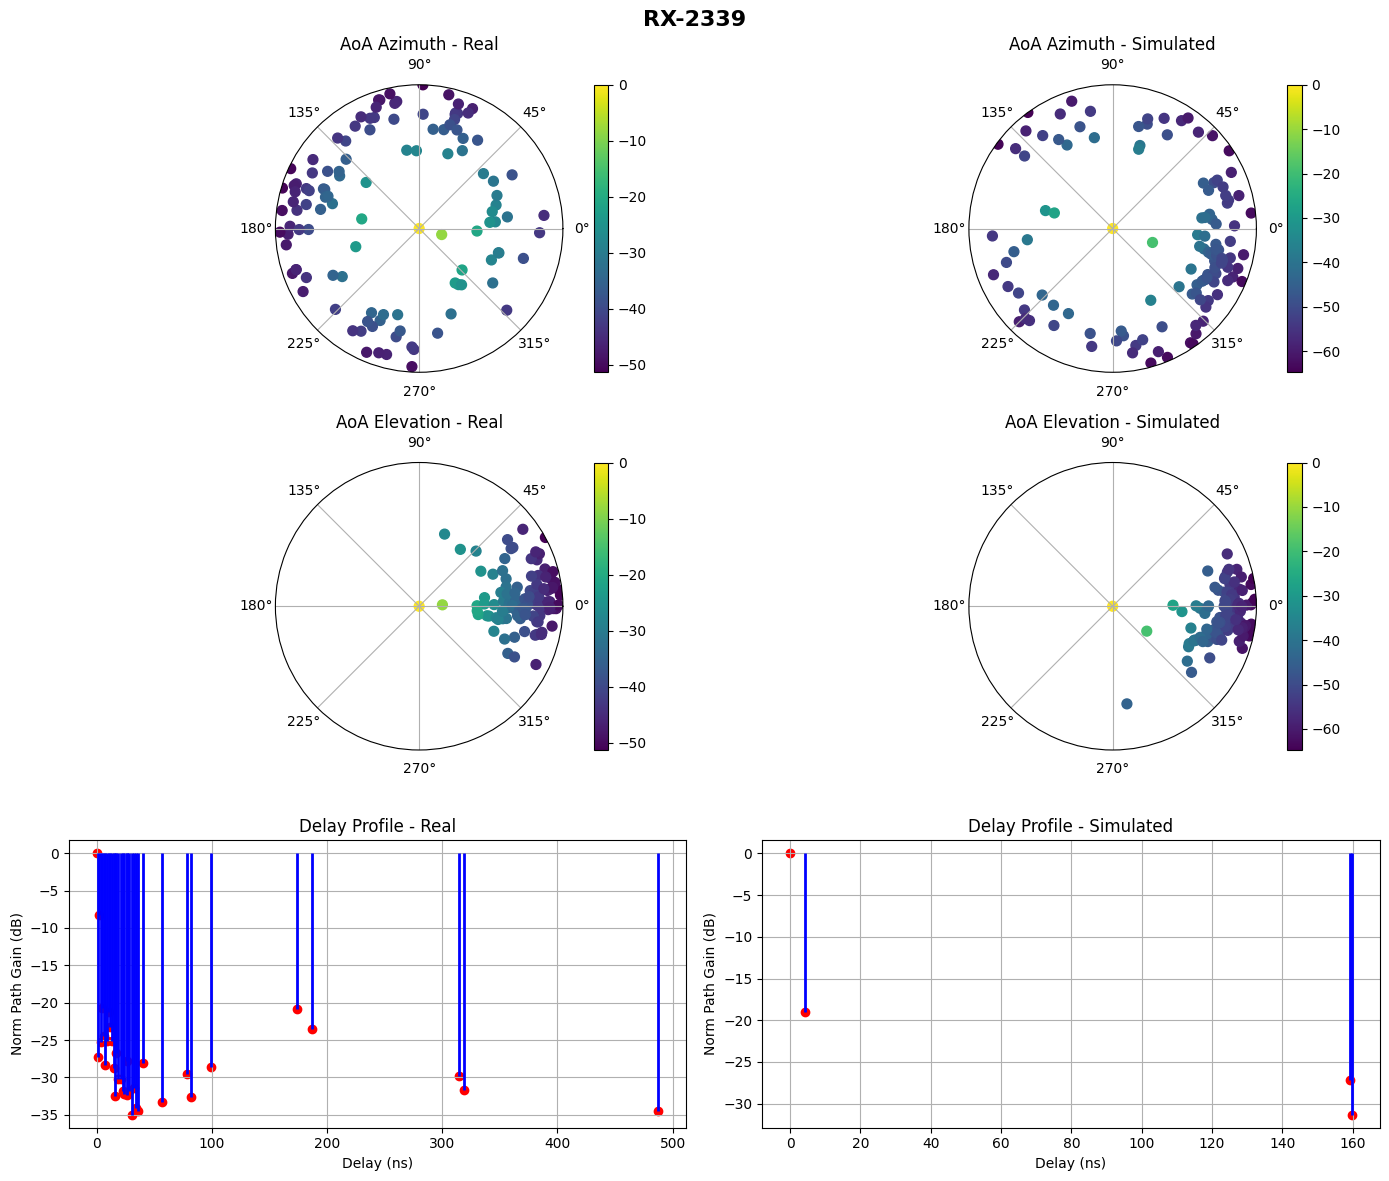

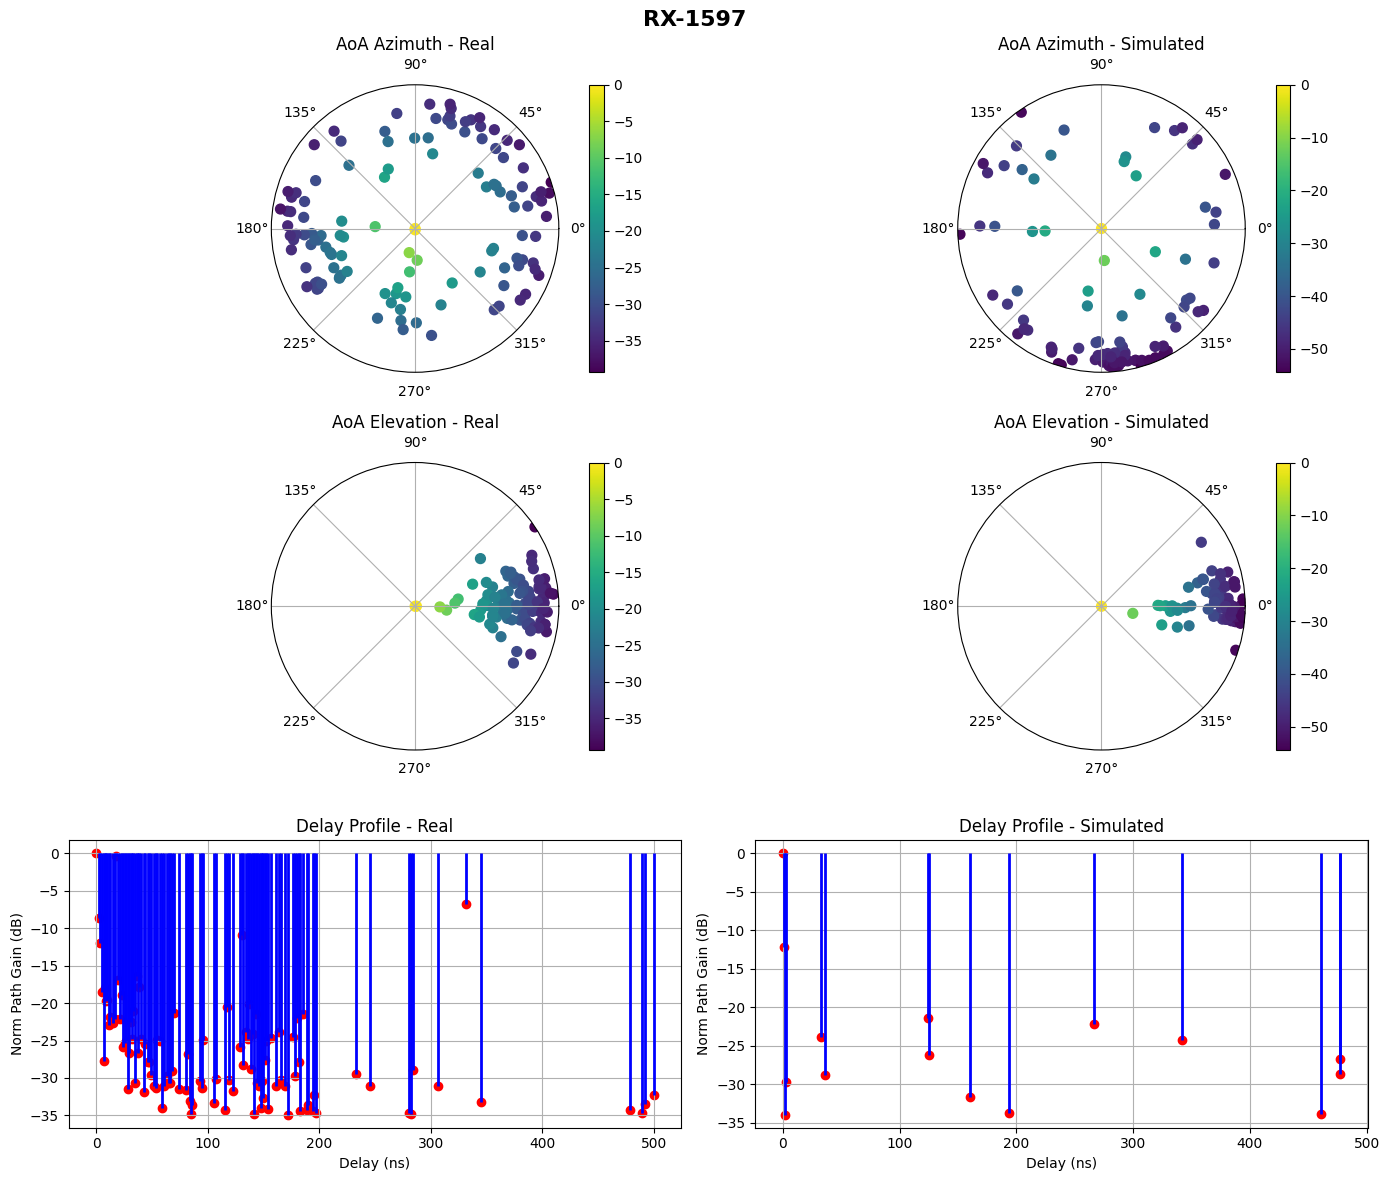

In [39]:
for rx_id in extremes_rx_id:
    merged_df_row = merged_df[merged_df['mea_idx'] == rx_id]
    if merged_df_row['is_outdoor'].iloc[0] == True:
        tmp_tau = merged_df_row["MPC_params_sector01"].values[0][:, 0]
        tmp_aoa_az = merged_df_row["MPC_params_sector01"].values[0][:, 1]
        tmp_aoa_el = merged_df_row["MPC_params_sector01"].values[0][:, 2]
        tmp_path_gain = -1.0*merged_df_row["MPC_params_sector01"].values[0][:, 3]

        strongest_pg_idx = np.argmax(tmp_path_gain)

        # Get Sionna results
        tmp_df = df[df["rx_id"] == rx_id]
        tmp_tau_sionna = (tmp_df["tau"].values * 1e9)  # Convert to nsec
        tmp_aoa_az_sionna = (90 - (tmp_df["phi_r"].values * 180 / np.pi)) % 360
        tmp_aoa_el_sionna = (90 - (tmp_df["theta_r"].values * 180 / np.pi)) % 360
        tmp_path_gain_sionna = 10 * np.log10(np.abs(tmp_df["a"].values)**2)
        tmp_ray_type_sionna = tmp_df["type"]
        
        # Apply threshold
        threshold_value = -140
        mask = tmp_path_gain_sionna >= threshold_value

        # Apply mask to all arrays
        tmp_tau_sionna = tmp_tau_sionna[mask]
        tmp_aoa_az_sionna = tmp_aoa_az_sionna[mask]
        tmp_aoa_el_sionna = tmp_aoa_el_sionna[mask]
        tmp_path_gain_sionna = tmp_path_gain_sionna[mask]

        tmp_pg_norm = normalize(tmp_path_gain)

        if len(tmp_path_gain_sionna) > 0:
            
            threshold_pg_sionna_norm = normalize(np.array(list(tmp_path_gain_sionna)))
            
            # Plot Comparisons
            compare_real_vs_sionna(
                    tmp_aoa_az, tmp_aoa_az_sionna,
                    tmp_aoa_el, tmp_aoa_el_sionna,
                    tmp_tau, tmp_tau_sionna,
                    tmp_pg_norm, threshold_pg_sionna_norm,
                    rx_id,
                    -35 # Delay norm power threshold value
            )